In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

df = pd.read_parquet('../data/processed/bookings_clean.parquet')
print("Shape:", df.shape)
df[['adr', 'hotel', 'market_segment', 'meal', 'stays_in_week_nights']].head()

Shape: (87389, 29)


,adr,hotel,market_segment,meal,stays_in_week_nights
0,0.0,Resort Hotel,Direct,BB,0
1,0.0,Resort Hotel,Direct,BB,0
2,75.0,Resort Hotel,Direct,BB,1
3,75.0,Resort Hotel,Corporate,BB,1
4,98.0,Resort Hotel,Online TA,BB,2


In [2]:
# Remove invalid ADR values
df = df[df['adr'] > 0]
df = df[df['adr'] < 1000]  # remove extreme outliers

print("Shape after cleaning ADR:", df.shape)
print("\nADR Statistics:")
print(df['adr'].describe().round(2))

Shape after cleaning ADR: (85609, 29)

ADR Statistics:
count    85609.00
mean       108.49
std         50.22
min          0.26
25%         74.48
50%         99.00
75%        135.00
max        510.00
Name: adr, dtype: float64


In [3]:
features = [
    'hotel', 'meal', 'market_segment', 'distribution_channel',
    'is_repeated_guest', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'arrival_date_month', 'arrival_date_week_number',
    'lead_time', 'customer_type', 'total_of_special_requests',
    'required_car_parking_spaces', 'booking_changes'
]

X = df[features]
y = df['adr']

print("Features shape:", X.shape)
print("Target (ADR) shape:", y.shape)

Features shape: (85609, 16)
Target (ADR) shape: (85609,)


In [4]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

le = LabelEncoder()
X = X.copy()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print("\nEncoding done!")
print(X.dtypes.value_counts())

Categorical columns: ['hotel', 'meal', 'market_segment', 'distribution_channel', 'arrival_date_month', 'customer_type']

Encoding done!
int64      9
int32      6
float64    1
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (68487, 16)
Test size: (17122, 16)


In [6]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train)
y_pred = rf_reg.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Mean Absolute Error): ${mae:.2f}")
print(f"RMSE (Root Mean Sq Error) : ${rmse:.2f}")
print(f"R2 Score                  : {r2:.4f}")

MAE  (Mean Absolute Error): $15.72
RMSE (Root Mean Sq Error) : $24.38
R2 Score                  : 0.7664


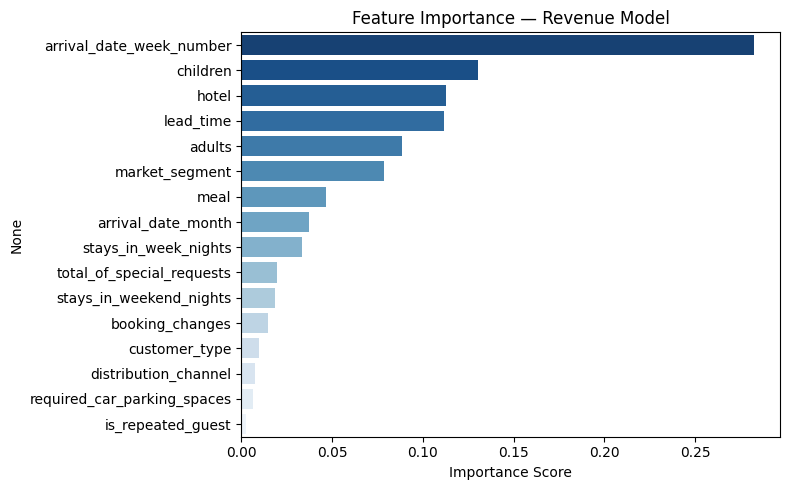

In [8]:
feat_importance = pd.Series(rf_reg.feature_importances_, index=features)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index, 
            hue=feat_importance.index, palette='Blues_r', legend=False)
plt.title('Feature Importance — Revenue Model')
plt.xlabel('Importance Score')
plt.tight_layout()

import os
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/04_revenue_feature_importance.png', dpi=150)
plt.show()

In [9]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_reg, '../models/revenue_model.pkl')
joblib.dump(scaler, '../models/revenue_scaler.pkl')
joblib.dump(features, '../models/revenue_features.pkl')

print("Revenue model saved!")

Revenue model saved!
